Instalacion de librerias

In [ ]:
!pip -q install psycopg2-binary sqlalchemy pandas numpy matplotlib tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 37.5 MB/s eta 0:00:00


Conexion a Render

In [ ]:
from getpass import getpass
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np

In [ ]:
DATABASE_URL = "URL Aqui"

# Ajuste del conector para SQLAlchemy + psycopg2
if DATABASE_URL.startswith("postgres://"):
    DATABASE_URL = DATABASE_URL.replace("postgres://", "postgresql+psycopg2://", 1)
elif DATABASE_URL.startswith("postgresql://"):
    DATABASE_URL = DATABASE_URL.replace("postgresql://", "postgresql+psycopg2://", 1)

engine = create_engine(
    DATABASE_URL,
    connect_args={"sslmode": "require"}
)

with engine.connect() as conn:
    resultado = conn.execute(text("SELECT current_database(), current_user;"))
    print(resultado.fetchone())

('botbi_rrhh_dj5x', 'botbi_user')


Creación de tablas

In [ ]:
ddl = """
DROP SCHEMA IF EXISTS rrhh CASCADE;
CREATE SCHEMA rrhh;

CREATE TABLE rrhh.departamento (
    id_departamento INT PRIMARY KEY,
    nombre VARCHAR(80) NOT NULL,
    centro_costo VARCHAR(30) NOT NULL
);

CREATE TABLE rrhh.puesto (
    id_puesto INT PRIMARY KEY,
    nombre VARCHAR(80) NOT NULL,
    nivel VARCHAR(30) NOT NULL,
    salario_min NUMERIC(10,2) NOT NULL,
    salario_max NUMERIC(10,2) NOT NULL
);

CREATE TABLE rrhh.empleado (
    id_empleado INT PRIMARY KEY,
    codigo_empleado VARCHAR(20) UNIQUE NOT NULL,
    nombres VARCHAR(120) NOT NULL,
    id_departamento INT NOT NULL REFERENCES rrhh.departamento(id_departamento),
    id_puesto INT NOT NULL REFERENCES rrhh.puesto(id_puesto),
    fecha_ingreso DATE NOT NULL,
    salario_base NUMERIC(10,2) NOT NULL,
    estado VARCHAR(20) NOT NULL CHECK (estado IN ('ACTIVO', 'INACTIVO'))
);

CREATE TABLE rrhh.asistencia (
    id_asistencia BIGSERIAL PRIMARY KEY,
    id_empleado INT NOT NULL REFERENCES rrhh.empleado(id_empleado),
    fecha_actividad DATE NOT NULL,
    hora_entrada TIME,
    hora_salida TIME,
    estado_asistencia VARCHAR(20) NOT NULL CHECK (
        estado_asistencia IN ('NORMAL', 'TARDE', 'AUSENTE', 'PERMISO')
    ),
    minutos_tardanza INT NOT NULL DEFAULT 0,
    horas_trabajadas NUMERIC(5,2) NOT NULL DEFAULT 0
);

CREATE TABLE rrhh.nomina (
    id_nomina BIGSERIAL PRIMARY KEY,
    periodo DATE NOT NULL,
    id_empleado INT NOT NULL REFERENCES rrhh.empleado(id_empleado),
    salario_base NUMERIC(10,2) NOT NULL,
    horas_extra NUMERIC(6,2) NOT NULL DEFAULT 0,
    bono NUMERIC(10,2) NOT NULL DEFAULT 0,
    descuento_isss NUMERIC(10,2) NOT NULL DEFAULT 0,
    descuento_afp NUMERIC(10,2) NOT NULL DEFAULT 0,
    descuento_renta NUMERIC(10,2) NOT NULL DEFAULT 0,
    otros_descuentos NUMERIC(10,2) NOT NULL DEFAULT 0,
    salario_neto NUMERIC(10,2) NOT NULL
);

CREATE TABLE rrhh.evaluacion_desempeno (
    id_evaluacion BIGSERIAL PRIMARY KEY,
    periodo DATE NOT NULL,
    id_empleado INT NOT NULL REFERENCES rrhh.empleado(id_empleado),
    puntualidad NUMERIC(5,2) NOT NULL,
    productividad NUMERIC(5,2) NOT NULL,
    calidad NUMERIC(5,2) NOT NULL,
    trabajo_equipo NUMERIC(5,2) NOT NULL,
    calificacion_total NUMERIC(5,2) NOT NULL,
    observacion VARCHAR(150)
);

CREATE INDEX idx_asistencia_empleado_fecha
ON rrhh.asistencia(id_empleado, fecha_actividad);

CREATE INDEX idx_nomina_periodo_empleado
ON rrhh.nomina(periodo, id_empleado);

CREATE INDEX idx_evaluacion_periodo_empleado
ON rrhh.evaluacion_desempeno(periodo, id_empleado);
"""

with engine.begin() as conn:
    conn.execute(text(ddl))

print("Estructura de base de datos creada correctamente.")


Estructura de base de datos creada correctamente.


Carga de catálogos

In [ ]:
departamentos = pd.DataFrame([
    [1, "Recursos Humanos", "CC-RRHH"],
    [2, "Operaciones", "CC-OPER"],
    [3, "Logística", "CC-LOG"],
    [4, "Tecnología", "CC-TI"],
    [5, "Finanzas", "CC-FIN"],
    [6, "Ventas", "CC-VTA"],
    [7, "Atención al Cliente", "CC-SAC"],
    [8, "Administración", "CC-ADM"]
], columns=["id_departamento", "nombre", "centro_costo"])

puestos = pd.DataFrame([
    [1, "Analista Junior", "Junior", 500, 750],
    [2, "Analista Senior", "Senior", 800, 1200],
    [3, "Coordinador", "Coordinación", 1200, 1800],
    [4, "Supervisor", "Supervisión", 900, 1400],
    [5, "Asistente Administrativo", "Operativo", 400, 650],
    [6, "Técnico de Soporte", "Técnico", 600, 1000],
    [7, "Especialista de Nómina", "Especialista", 900, 1300],
    [8, "Auxiliar de Logística", "Operativo", 400, 700],
    [9, "Jefe de Área", "Jefatura", 1800, 2500],
    [10, "Gerente", "Gerencia", 2500, 4000]
], columns=["id_puesto", "nombre", "nivel", "salario_min", "salario_max"])

departamentos.to_sql(
    "departamento",
    engine,
    schema="rrhh",
    if_exists="append",
    index=False
)

puestos.to_sql(
    "puesto",
    engine,
    schema="rrhh",
    if_exists="append",
    index=False
)

print("Catálogos cargados correctamente.")


Catálogos cargados correctamente.


Generación de empleados.

In [ ]:
rng = np.random.default_rng(42)

N_EMPLEADOS = 1000

nombres_base = [
    "Carlos", "María", "José", "Ana", "Luis", "Sofía", "Miguel", "Daniela",
    "Jorge", "Verónica", "Ricardo", "Gabriela", "Fernando", "Lucía", "Roberto",
    "Patricia", "Hugo", "Elena", "Francisco", "Andrea"
]

apellidos_base = [
    "Gómez", "Rodríguez", "Martínez", "Hernández", "López", "Machado",
    "Ramírez", "Torres", "Flores", "Castro", "Morales", "Vásquez",
    "Reyes", "Cruz", "Mendoza", "Rivas"
]

id_puestos = rng.integers(1, 11, N_EMPLEADOS)
id_departamentos = rng.integers(1, 9, N_EMPLEADOS)

puestos_dict = puestos.set_index("id_puesto")[["salario_min", "salario_max"]].to_dict("index")

salarios = []
for id_puesto in id_puestos:
    minimo = puestos_dict[id_puesto]["salario_min"]
    maximo = puestos_dict[id_puesto]["salario_max"]
    salarios.append(round(float(rng.uniform(minimo, maximo)), 2))

fechas = pd.date_range("2018-01-01", "2025-12-31", freq="D")
fechas_ingreso = rng.choice(fechas, N_EMPLEADOS)

empleados = pd.DataFrame({
    "id_empleado": range(1, N_EMPLEADOS + 1),
    "codigo_empleado": [f"EMP{str(i).zfill(5)}" for i in range(1, N_EMPLEADOS + 1)],
    "nombres": [
        f"{rng.choice(nombres_base)} {rng.choice(apellidos_base)} {rng.choice(apellidos_base)}"
        for _ in range(N_EMPLEADOS)
    ],
    "id_departamento": id_departamentos,
    "id_puesto": id_puestos,
    "fecha_ingreso": pd.to_datetime(fechas_ingreso).date,
    "salario_base": salarios,
    "estado": rng.choice(["ACTIVO", "INACTIVO"], N_EMPLEADOS, p=[0.92, 0.08])
})

empleados.to_sql(
    "empleado",
    engine,
    schema="rrhh",
    if_exists="append",
    index=False,
    chunksize=5000
)

print("Empleados cargados:", len(empleados))


Empleados cargados: 1000


Generación de asistencia.

In [ ]:
N_ASISTENCIA = 100000

fechas_asistencia = pd.date_range("2026-01-01", "2026-05-31", freq="D")

estado_asistencia = rng.choice(
    ["NORMAL", "TARDE", "AUSENTE", "PERMISO"],
    N_ASISTENCIA,
    p=[0.72, 0.16, 0.07, 0.05]
)

minutos_tardanza = np.where(
    estado_asistencia == "TARDE",
    rng.integers(5, 91, N_ASISTENCIA),
    0
)

def calcular_hora_entrada(estado, tardanza):
    if estado == "AUSENTE":
        return None
    if estado == "TARDE":
        hora = 8 + int(tardanza) // 60
        minuto = int(tardanza) % 60
        return f"{hora:02d}:{minuto:02d}:00"
    return "08:00:00"

hora_entrada = [
    calcular_hora_entrada(estado, tardanza)
    for estado, tardanza in zip(estado_asistencia, minutos_tardanza)
]

hora_salida = [
    None if estado == "AUSENTE" else "17:00:00"
    for estado in estado_asistencia
]

horas_trabajadas = np.where(
    estado_asistencia == "AUSENTE",
    0,
    np.round(np.clip(rng.normal(8, 0.6, N_ASISTENCIA), 5, 10), 2)
)

asistencia = pd.DataFrame({
    "id_empleado": rng.integers(1, N_EMPLEADOS + 1, N_ASISTENCIA),
    "fecha_actividad": pd.to_datetime(rng.choice(fechas_asistencia, N_ASISTENCIA)).date,
    "hora_entrada": hora_entrada,
    "hora_salida": hora_salida,
    "estado_asistencia": estado_asistencia,
    "minutos_tardanza": minutos_tardanza,
    "horas_trabajadas": horas_trabajadas
})

try:
    with engine.connect() as connection:
        with connection.begin(): # This manages the transaction
            asistencia.to_sql(
                "asistencia",
                connection, # Pass the connection explicitly
                schema="rrhh",
                if_exists="append",
                index=False,
                chunksize=5000,
                method="multi"
            )
    print("Registros de asistencia cargados:", len(asistencia))
except Exception as e:
    print(f"Error al cargar registros de asistencia: {e}")

Registros de asistencia cargados: 100000


Generación de nómina.

In [ ]:
periodos_nomina = pd.date_range("2025-01-01", "2026-05-01", freq="MS")

base_nomina = empleados[["id_empleado", "salario_base"]].copy()
nomina = base_nomina.merge(
    pd.DataFrame({"periodo": periodos_nomina}),
    how="cross"
)

n = len(nomina)

nomina["horas_extra"] = rng.integers(0, 21, n)
nomina["bono"] = rng.choice([0, 25, 50, 75, 100], n, p=[0.45, 0.20, 0.15, 0.12, 0.08])

nomina["descuento_isss"] = np.round(nomina["salario_base"] * 0.03, 2)
nomina["descuento_afp"] = np.round(nomina["salario_base"] * 0.0725, 2)
nomina["descuento_renta"] = np.where(
    nomina["salario_base"] > 700,
    np.round(nomina["salario_base"] * 0.10, 2),
    0
)
nomina["otros_descuentos"] = rng.choice([0, 5, 10, 15, 20], n)

valor_hora_extra = np.round((nomina["salario_base"] / 30 / 8) * 1.5, 2)
monto_horas_extra = np.round(nomina["horas_extra"] * valor_hora_extra, 2)

nomina["salario_neto"] = np.round(
    nomina["salario_base"]
    + monto_horas_extra
    + nomina["bono"]
    - nomina["descuento_isss"]
    - nomina["descuento_afp"]
    - nomina["descuento_renta"]
    - nomina["otros_descuentos"],
    2
)

nomina = nomina[
    [
        "periodo", "id_empleado", "salario_base", "horas_extra", "bono",
        "descuento_isss", "descuento_afp", "descuento_renta",
        "otros_descuentos", "salario_neto"
    ]
]

nomina.to_sql(
    "nomina",
    engine,
    schema="rrhh",
    if_exists="append",
    index=False,
    chunksize=5000,
    method="multi"
)

print("Registros de nómina cargados:", len(nomina))


Registros de nómina cargados: 17000


Generación de evaluaciones.

In [ ]:
periodos_eval = pd.to_datetime([
    "2025-03-01", "2025-06-01", "2025-09-01", "2025-12-01", "2026-03-01"
])

evaluacion = empleados[["id_empleado"]].merge(
    pd.DataFrame({"periodo": periodos_eval}),
    how="cross"
)

n = len(evaluacion)

evaluacion["puntualidad"] = np.round(rng.uniform(60, 100, n), 2)
evaluacion["productividad"] = np.round(rng.uniform(60, 100, n), 2)
evaluacion["calidad"] = np.round(rng.uniform(60, 100, n), 2)
evaluacion["trabajo_equipo"] = np.round(rng.uniform(60, 100, n), 2)

evaluacion["calificacion_total"] = np.round(
    (
        evaluacion["puntualidad"]
        + evaluacion["productividad"]
        + evaluacion["calidad"]
        + evaluacion["trabajo_equipo"]
    ) / 4,
    2
)

evaluacion["observacion"] = np.where(
    evaluacion["calificacion_total"] >= 85,
    "Desempeño sobresaliente",
    np.where(
        evaluacion["calificacion_total"] >= 70,
        "Desempeño aceptable",
        "Requiere seguimiento"
    )
)

evaluacion.to_sql(
    "evaluacion_desempeno",
    engine,
    schema="rrhh",
    if_exists="append",
    index=False,
    chunksize=5000,
    method="multi"
)

print("Registros de evaluación cargados:", len(evaluacion))

Registros de evaluación cargados: 5000


Validación de registros

In [ ]:
validacion_sql = """
SELECT 'departamento' AS tabla, COUNT(*) AS registros FROM rrhh.departamento
UNION ALL
SELECT 'puesto', COUNT(*) FROM rrhh.puesto
UNION ALL
SELECT 'empleado', COUNT(*) FROM rrhh.empleado
UNION ALL
SELECT 'asistencia', COUNT(*) FROM rrhh.asistencia
UNION ALL
SELECT 'nomina', COUNT(*) FROM rrhh.nomina
UNION ALL
SELECT 'evaluacion_desempeno', COUNT(*) FROM rrhh.evaluacion_desempeno;
"""

pd.read_sql_query(validacion_sql, engine)

,tabla,registros
0,departamento,8
1,puesto,10
2,empleado,1000
3,asistencia,200000
4,nomina,17000
5,evaluacion_desempeno,5000


Creación de vistas BI

In [ ]:
views_sql = """
CREATE OR REPLACE VIEW rrhh.vw_kpi_general AS
SELECT
    COUNT(*) AS total_empleados,
    COUNT(*) FILTER (WHERE estado = 'ACTIVO') AS empleados_activos,
    COUNT(*) FILTER (WHERE estado = 'INACTIVO') AS empleados_inactivos,
    ROUND(AVG(salario_base), 2) AS salario_promedio,
    ROUND(MIN(salario_base), 2) AS salario_minimo,
    ROUND(MAX(salario_base), 2) AS salario_maximo
FROM rrhh.empleado;

CREATE OR REPLACE VIEW rrhh.vw_resumen_colaboradores AS
SELECT
    d.nombre AS departamento,
    p.nombre AS puesto,
    e.estado,
    COUNT(*) AS cantidad_empleados,
    ROUND(AVG(e.salario_base), 2) AS salario_promedio
FROM rrhh.empleado e
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
INNER JOIN rrhh.puesto p
    ON e.id_puesto = p.id_puesto
GROUP BY d.nombre, p.nombre, e.estado;

CREATE OR REPLACE VIEW rrhh.vw_kpi_asistencia_mensual AS
SELECT
    DATE_TRUNC('month', a.fecha_actividad)::DATE AS mes,
    d.nombre AS departamento,
    COUNT(*) AS total_registros,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'NORMAL') AS asistencias_normales,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') AS tardanzas,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'AUSENTE') AS ausencias,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'PERMISO') AS permisos,
    ROUND(AVG(a.horas_trabajadas), 2) AS horas_promedio,
    ROUND(AVG(a.minutos_tardanza), 2) AS tardanza_promedio_minutos,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE')
        / NULLIF(COUNT(*), 0),
        2
    ) AS porcentaje_tardanza,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE a.estado_asistencia = 'AUSENTE')
        / NULLIF(COUNT(*), 0),
        2
    ) AS porcentaje_ausencia
FROM rrhh.asistencia a
INNER JOIN rrhh.empleado e
    ON a.id_empleado = e.id_empleado
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
GROUP BY DATE_TRUNC('month', a.fecha_actividad)::DATE, d.nombre;

CREATE OR REPLACE VIEW rrhh.vw_kpi_nomina_mensual AS
SELECT
    n.periodo AS mes,
    d.nombre AS departamento,
    COUNT(*) AS cantidad_pagos,
    ROUND(SUM(n.salario_base), 2) AS total_salario_base,
    ROUND(SUM(n.bono), 2) AS total_bonos,
    ROUND(
        SUM(n.descuento_isss + n.descuento_afp + n.descuento_renta + n.otros_descuentos),
        2
    ) AS total_descuentos,
    ROUND(SUM(n.salario_neto), 2) AS total_salario_neto,
    ROUND(AVG(n.salario_neto), 2) AS salario_neto_promedio
FROM rrhh.nomina n
INNER JOIN rrhh.empleado e
    ON n.id_empleado = e.id_empleado
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
GROUP BY n.periodo, d.nombre;

CREATE OR REPLACE VIEW rrhh.vw_top_tardanzas AS
SELECT
    DATE_TRUNC('month', a.fecha_actividad)::DATE AS mes,
    e.codigo_empleado,
    e.nombres,
    d.nombre AS departamento,
    p.nombre AS puesto,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') AS total_tardanzas,
    SUM(a.minutos_tardanza) AS total_minutos_tardanza
FROM rrhh.asistencia a
INNER JOIN rrhh.empleado e
    ON a.id_empleado = e.id_empleado
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
INNER JOIN rrhh.puesto p
    ON e.id_puesto = p.id_puesto
GROUP BY
    DATE_TRUNC('month', a.fecha_actividad)::DATE,
    e.codigo_empleado,
    e.nombres,
    d.nombre,
    p.nombre
HAVING COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') > 0;

CREATE OR REPLACE VIEW rrhh.vw_desempeno_departamento AS
SELECT
    ev.periodo,
    d.nombre AS departamento,
    COUNT(*) AS empleados_evaluados,
    ROUND(AVG(ev.puntualidad), 2) AS puntualidad_promedio,
    ROUND(AVG(ev.productividad), 2) AS productividad_promedio,
    ROUND(AVG(ev.calidad), 2) AS calidad_promedio,
    ROUND(AVG(ev.trabajo_equipo), 2) AS trabajo_equipo_promedio,
    ROUND(AVG(ev.calificacion_total), 2) AS calificacion_total_promedio
FROM rrhh.evaluacion_desempeno ev
INNER JOIN rrhh.empleado e
    ON ev.id_empleado = e.id_empleado
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
GROUP BY ev.periodo, d.nombre;

CREATE OR REPLACE VIEW rrhh.vw_alertas_rrhh AS
SELECT
    DATE_TRUNC('month', a.fecha_actividad)::DATE AS mes,
    e.codigo_empleado,
    e.nombres,
    d.nombre AS departamento,
    p.nombre AS puesto,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') AS total_tardanzas,
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'AUSENTE') AS total_ausencias,
    SUM(a.minutos_tardanza) AS minutos_tardanza_acumulados,
    CASE
        WHEN COUNT(*) FILTER (WHERE a.estado_asistencia = 'AUSENTE') >= 3
            THEN 'ALERTA POR AUSENCIAS'
        WHEN COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') >= 5
            THEN 'ALERTA POR TARDANZAS'
        WHEN SUM(a.minutos_tardanza) >= 180
            THEN 'ALERTA POR MINUTOS DE TARDANZA'
        ELSE 'SIN ALERTA'
    END AS tipo_alerta
FROM rrhh.asistencia a
INNER JOIN rrhh.empleado e
    ON a.id_empleado = e.id_empleado
INNER JOIN rrhh.departamento d
    ON e.id_departamento = d.id_departamento
INNER JOIN rrhh.puesto p
    ON e.id_puesto = p.id_puesto
GROUP BY
    DATE_TRUNC('month', a.fecha_actividad)::DATE,
    e.codigo_empleado,
    e.nombres,
    d.nombre,
    p.nombre
HAVING
    COUNT(*) FILTER (WHERE a.estado_asistencia = 'AUSENTE') >= 3
    OR COUNT(*) FILTER (WHERE a.estado_asistencia = 'TARDE') >= 5
    OR SUM(a.minutos_tardanza) >= 180;
"""

with engine.begin() as conn:
    conn.execute(text(views_sql))

print("Vistas BI creadas correctamente.")

Vistas BI creadas correctamente.


In [ ]:
pd.read_sql_query("SELECT * FROM rrhh.vw_kpi_general;", engine)
pd.read_sql_query("""
SELECT *
FROM rrhh.vw_kpi_asistencia_mensual
ORDER BY mes DESC, departamento
LIMIT 20;
""", engine)
pd.read_sql_query("""
SELECT *
FROM rrhh.vw_kpi_nomina_mensual
ORDER BY mes DESC, departamento
LIMIT 20;
""", engine)


,mes,departamento,cantidad_pagos,total_salario_base,total_bonos,total_descuentos,total_salario_neto,salario_neto_promedio
0,2026-05-01,Administración,126,148720.70,4125.0,28898.06,133151.80,1056.76
1,2026-05-01,Atención al Cliente,127,168126.73,3275.0,33206.46,148774.74,1171.45
2,2026-05-01,Finanzas,127,148621.12,4300.0,29378.29,132302.16,1041.75
3,2026-05-01,Logística,127,167346.37,3725.0,33079.65,148543.91,1169.64
4,2026-05-01,Operaciones,124,147952.22,3675.0,28623.90,132677.24,1069.98
5,2026-05-01,Recursos Humanos,130,162462.25,3925.0,32170.84,143856.33,1106.59
6,2026-05-01,Tecnología,126,156167.79,3925.0,30878.43,138638.99,1100.31
7,2026-05-01,Ventas,113,143558.97,3150.0,27998.19,127495.54,1128.28
8,2026-04-01,Administración,126,148720.70,3475.0,28923.06,133101.09,1056.36
9,2026-04-01,Atención al Cliente,127,168126.73,3275.0,33161.46,149338.21,1175.89


Bot de consultas

In [ ]:
import unicodedata
from IPython.display import display

def normalizar_texto(texto):
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

departamentos_validos = pd.read_sql_query(
    "SELECT LOWER(nombre) AS nombre FROM rrhh.departamento;",
    engine
)["nombre"].tolist()

def extraer_departamento(pregunta):
    pregunta_norm = normalizar_texto(pregunta)
    for depto in departamentos_validos:
        depto_norm = normalizar_texto(depto)
        if depto_norm in pregunta_norm:
            return depto
    return None

def detectar_intencion(pregunta):
    p = normalizar_texto(pregunta)

    if "ayuda" in p or "opciones" in p:
        return "ayuda"

    if "general" in p or "resumen" in p or "empleados activos" in p:
        return "general"

    if "colaborador" in p or "empleado" in p or "personal" in p:
        return "colaboradores"

    if "asistencia" in p or "ausencia" in p or "ausencias" in p:
        return "asistencia"

    if "top" in p and ("tardanza" in p or "tardanzas" in p):
        return "top_tardanzas"

    if "tardanza" in p or "tardanzas" in p:
        return "top_tardanzas"

    if "nomina" in p or "planilla" in p or "salario" in p:
        return "nomina"

    if "desempeno" in p or "desempeño" in pregunta.lower() or "evaluacion" in p or "evaluación" in pregunta.lower():
        return "desempeno"

    if "alerta" in p or "alertas" in p or "riesgo" in p:
        return "alertas"

    return "no_entendido"


In [ ]:
consultas_sql = {
    "general": """
        SELECT *
        FROM rrhh.vw_kpi_general;
    """,

    "colaboradores": """
        SELECT *
        FROM rrhh.vw_resumen_colaboradores
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY departamento, puesto, estado
        LIMIT 50;
    """,

    "asistencia": """
        SELECT *
        FROM rrhh.vw_kpi_asistencia_mensual
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY mes DESC, departamento
        LIMIT 50;
    """,

    "top_tardanzas": """
        SELECT *
        FROM rrhh.vw_top_tardanzas
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY total_minutos_tardanza DESC
        LIMIT 15;
    """,

    "nomina": """
        SELECT *
        FROM rrhh.vw_kpi_nomina_mensual
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY mes DESC, departamento
        LIMIT 50;
    """,

    "desempeno": """
        SELECT *
        FROM rrhh.vw_desempeno_departamento
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY periodo DESC, departamento
        LIMIT 50;
    """,

    "alertas": """
        SELECT *
        FROM rrhh.vw_alertas_rrhh
        WHERE (:depto IS NULL OR LOWER(departamento) = :depto)
        ORDER BY mes DESC, minutos_tardanza_acumulados DESC
        LIMIT 30;
    """
}


In [ ]:
def bot_bi_rrhh(pregunta):
    intencion = detectar_intencion(pregunta)
    departamento = extraer_departamento(pregunta)

    if intencion == "ayuda":
        ayuda = pd.DataFrame({
            "Ejemplos de preguntas": [
                "Dame un resumen general",
                "Cuántos empleados activos tengo",
                "Muéstrame colaboradores por departamento",
                "Dame asistencia mensual",
                "Dame asistencia mensual de Tecnología",
                "Muéstrame el top de tardanzas",
                "Dame las tardanzas de Operaciones",
                "Muéstrame la nómina mensual",
                "Dame la nómina de Finanzas",
                "Cómo va el desempeño por departamento",
                "Muéstrame alertas de Recursos Humanos"
            ]
        })
        return ayuda

    if intencion == "no_entendido":
        return pd.DataFrame({
            "Mensaje": [
                "No entendí la pregunta. Escribe 'ayuda' para ver ejemplos de consultas disponibles."
            ]
        })

    sql = consultas_sql[intencion]

    with engine.connect() as conn:
        df = pd.read_sql_query(
            text(sql),
            conn,
            params={"depto": departamento}
        )

    if df.empty:
        return pd.DataFrame({
            "Mensaje": [
                "No se encontraron datos para la consulta solicitada."
            ]
        })

    return df


Pruebas y gráficos

In [ ]:
bot_bi_rrhh("ayuda")

,Ejemplos de preguntas
0,Dame un resumen general
1,Cuántos empleados activos tengo
2,Muéstrame colaboradores por departamento
3,Dame asistencia mensual
4,Dame asistencia mensual de Tecnología
5,Muéstrame el top de tardanzas
6,Dame las tardanzas de Operaciones
7,Muéstrame la nómina mensual
8,Dame la nómina de Finanzas
9,Cómo va el desempeño por departamento


In [ ]:
bot_bi_rrhh("Dame un resumen general")

,total_empleados,empleados_activos,empleados_inactivos,salario_promedio,salario_minimo,salario_maximo
0,1000,942,58,1242.96,403.31,3990.28


In [ ]:
bot_bi_rrhh("Muéstrame asistencia mensual")

,mes,departamento,total_registros,asistencias_normales,tardanzas,ausencias,permisos,horas_promedio,tardanza_promedio_minutos,porcentaje_tardanza,porcentaje_ausencia
0,2026-05-01,Administración,5232,3759,849,348,276,7.49,7.80,16.23,6.65
1,2026-05-01,Atención al Cliente,5354,3891,817,385,261,7.44,6.98,15.26,7.19
2,2026-05-01,Finanzas,5212,3692,845,368,307,7.44,7.64,16.21,7.06
3,2026-05-01,Logística,5224,3705,862,377,280,7.42,7.97,16.50,7.22
4,2026-05-01,Operaciones,5140,3692,800,382,266,7.41,7.35,15.56,7.43
5,2026-05-01,Recursos Humanos,5399,3870,883,390,256,7.42,7.85,16.35,7.22
6,2026-05-01,Tecnología,5198,3733,817,372,276,7.43,7.20,15.72,7.16
7,2026-05-01,Ventas,4545,3259,748,320,218,7.45,7.85,16.46,7.04
8,2026-04-01,Administración,5084,3674,792,374,244,7.40,7.33,15.58,7.36
9,2026-04-01,Atención al Cliente,4953,3568,821,317,247,7.49,7.86,16.58,6.40


In [ ]:
bot_bi_rrhh("Dame asistencia mensual de Tecnología")

,mes,departamento,total_registros,asistencias_normales,tardanzas,ausencias,permisos,horas_promedio,tardanza_promedio_minutos,porcentaje_tardanza,porcentaje_ausencia
0,2026-05-01,Tecnología,5198,3733,817,372,276,7.43,7.20,15.72,7.16
1,2026-04-01,Tecnología,5102,3681,805,346,270,7.46,7.64,15.78,6.78
2,2026-03-01,Tecnología,5281,3807,818,377,279,7.42,7.31,15.49,7.14
3,2026-02-01,Tecnología,4571,3248,758,332,233,7.43,8.15,16.58,7.26
4,2026-01-01,Tecnología,5307,3802,853,389,263,7.42,7.48,16.07,7.33


In [ ]:
bot_bi_rrhh("Muéstrame el top de tardanzas")

,mes,codigo_empleado,nombres,departamento,puesto,total_tardanzas,total_minutos_tardanza
0,2026-01-01,EMP00780,Daniela Rodríguez Castro,Ventas,Jefe de Área,15,854
1,2026-05-01,EMP00952,Ricardo Vásquez Cruz,Finanzas,Supervisor,17,848
2,2026-05-01,EMP00273,Jorge Mendoza Ramírez,Administración,Analista Senior,14,814
3,2026-04-01,EMP00730,María López Gómez,Recursos Humanos,Especialista de Nómina,11,808
4,2026-01-01,EMP00646,Miguel Torres López,Logística,Supervisor,13,801
5,2026-03-01,EMP00891,María Torres Vásquez,Operaciones,Analista Junior,15,799
6,2026-01-01,EMP00436,Daniela Reyes Rodríguez,Recursos Humanos,Analista Senior,13,795
7,2026-01-01,EMP00271,Lucía Morales López,Logística,Coordinador,14,790
8,2026-05-01,EMP00114,Verónica López Castro,Logística,Asistente Administrativo,15,786
9,2026-01-01,EMP00711,Miguel Reyes Reyes,Logística,Especialista de Nómina,16,779


In [ ]:
bot_bi_rrhh("Dame la nómina de Finanzas")

,mes,departamento,cantidad_pagos,total_salario_base,total_bonos,total_descuentos,total_salario_neto,salario_neto_promedio
0,2026-05-01,Finanzas,127,148621.12,4300.0,29378.29,132302.16,1041.75
1,2026-04-01,Finanzas,127,148621.12,3225.0,29208.29,131267.58,1033.60
2,2026-03-01,Finanzas,127,148621.12,4200.0,29183.29,133162.40,1048.52
3,2026-02-01,Finanzas,127,148621.12,3950.0,29323.29,132330.36,1041.97
4,2026-01-01,Finanzas,127,148621.12,3875.0,29093.29,131834.62,1038.07
5,2025-12-01,Finanzas,127,148621.12,3500.0,29198.29,132419.57,1042.67
6,2025-11-01,Finanzas,127,148621.12,3800.0,29198.29,131791.25,1037.73
7,2025-10-01,Finanzas,127,148621.12,3825.0,29098.29,131331.57,1034.11
8,2025-09-01,Finanzas,127,148621.12,3600.0,29298.29,131528.51,1035.66
9,2025-08-01,Finanzas,127,148621.12,3525.0,29073.29,132332.47,1041.99


In [ ]:
bot_bi_rrhh("Muéstrame alertas de Recursos Humanos")

,mes,codigo_empleado,nombres,departamento,puesto,total_tardanzas,total_ausencias,minutos_tardanza_acumulados,tipo_alerta
0,2026-05-01,EMP00869,María López Flores,Recursos Humanos,Asistente Administrativo,12,3,717,ALERTA POR AUSENCIAS
1,2026-05-01,EMP00453,Lucía Gómez Gómez,Recursos Humanos,Asistente Administrativo,9,1,664,ALERTA POR TARDANZAS
2,2026-05-01,EMP00531,Carlos Rivas Machado,Recursos Humanos,Técnico de Soporte,12,5,637,ALERTA POR AUSENCIAS
3,2026-05-01,EMP00834,Luis Cruz Rodríguez,Recursos Humanos,Analista Senior,14,4,606,ALERTA POR AUSENCIAS
4,2026-05-01,EMP00019,Carlos Mendoza Rivas,Recursos Humanos,Jefe de Área,11,2,604,ALERTA POR TARDANZAS
5,2026-05-01,EMP00240,Roberto Gómez Torres,Recursos Humanos,Especialista de Nómina,10,4,602,ALERTA POR AUSENCIAS
6,2026-05-01,EMP00624,María Martínez Flores,Recursos Humanos,Asistente Administrativo,9,2,600,ALERTA POR TARDANZAS
7,2026-05-01,EMP00842,Miguel Ramírez Rodríguez,Recursos Humanos,Especialista de Nómina,11,3,561,ALERTA POR AUSENCIAS
8,2026-05-01,EMP00682,Elena Cruz Rodríguez,Recursos Humanos,Analista Senior,10,2,556,ALERTA POR TARDANZAS
9,2026-05-01,EMP00619,Elena Mendoza Vásquez,Recursos Humanos,Analista Junior,11,3,548,ALERTA POR AUSENCIAS


In [ ]:
print("Bot BI RRHH iniciado.")
print("Escribe 'ayuda' para ver ejemplos.")
print("Escribe 'salir' para finalizar.")

while True:
    pregunta = input("\nPregunta al Bot BI: ")

    if pregunta.lower().strip() in ["salir", "exit", "fin"]:
        print("Bot finalizado.")
        break

    respuesta = bot_bi_rrhh(pregunta)
    display(respuesta)


Bot BI RRHH iniciado.
Escribe 'ayuda' para ver ejemplos.
Escribe 'salir' para finalizar.

Pregunta al Bot BI: ayuda


,Ejemplos de preguntas
0,Dame un resumen general
1,Cuántos empleados activos tengo
2,Muéstrame colaboradores por departamento
3,Dame asistencia mensual
4,Dame asistencia mensual de Tecnología
5,Muéstrame el top de tardanzas
6,Dame las tardanzas de Operaciones
7,Muéstrame la nómina mensual
8,Dame la nómina de Finanzas
9,Cómo va el desempeño por departamento



Pregunta al Bot BI: dame un resumen general


,total_empleados,empleados_activos,empleados_inactivos,salario_promedio,salario_minimo,salario_maximo
0,1000,942,58,1242.96,403.31,3990.28



Pregunta al Bot BI: salir
Bot finalizado.


In [ ]:
import matplotlib.pyplot as plt

def graficar_asistencia_departamento(departamento=None):
    pregunta = "asistencia mensual"
    if departamento:
        pregunta += f" de {departamento}"

    df = bot_bi_rrhh(pregunta)

    if "mes" not in df.columns or "porcentaje_tardanza" not in df.columns:
        print("La consulta no tiene datos graficables.")
        return

    df["mes"] = pd.to_datetime(df["mes"])
    resumen = df.groupby("mes")["porcentaje_tardanza"].mean().reset_index()

    plt.figure(figsize=(10, 5))
    plt.plot(resumen["mes"], resumen["porcentaje_tardanza"], marker="o")
    plt.title("Porcentaje de tardanza mensual")
    plt.xlabel("Mes")
    plt.ylabel("% Tardanza")
    plt.grid(True)
    plt.show()


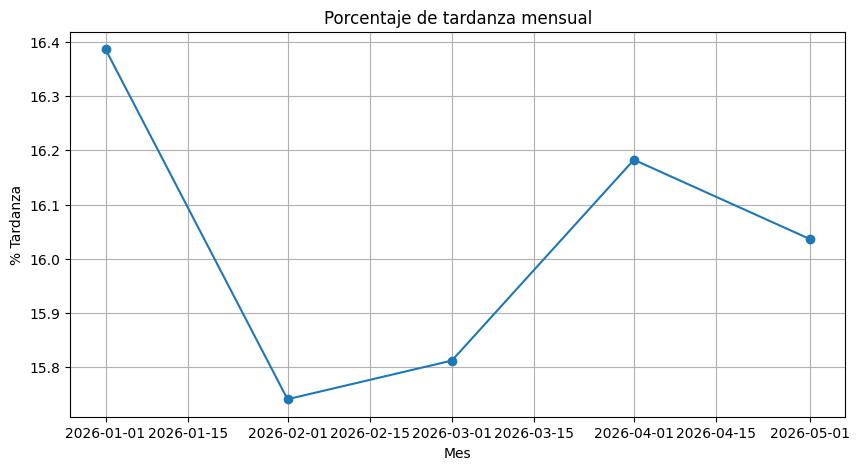

In [ ]:
graficar_asistencia_departamento()

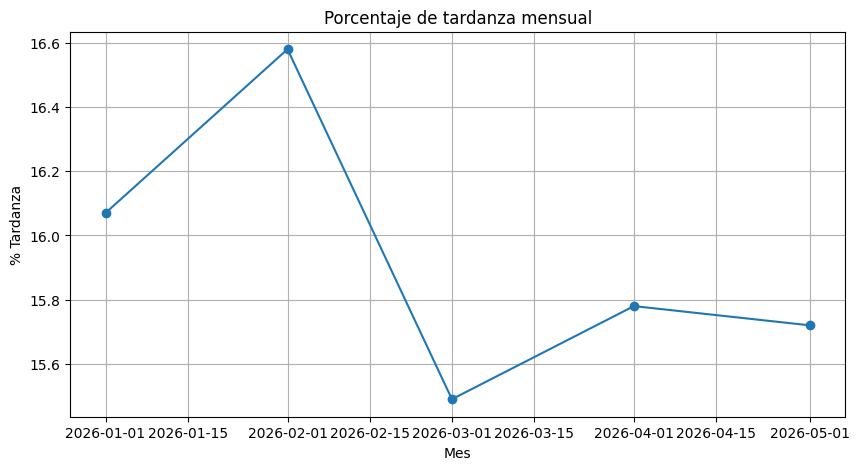

In [ ]:
graficar_asistencia_departamento("Tecnología")